# T3 · How backpropagation finds gradients

Unit 2 · Training, step by step.

Trace how the loss depends on learned numbers, from one numerical nudge to the complete computation graph.

**Use:** download this notebook, then upload it through Colab’s File → Upload notebook, or run it in Jupyter. No private clone or GPU is needed. Every section has a checked example, exercise and solution.

**Evidence:** small calculations are illustrative; the pinned checkpoint is the original Unit 1 model. New training runs are your experiments, with a corrected all-valid-start sampler. The historical replay keeps its original sampler.

**Environment:** tested with PyTorch 2.10 on CPU. On a local installation, install torch, numpy, matplotlib, jupyter and ipykernel.

**Notebook collection:** [Tiny labs](https://github.com/gkiri/tiny_repo). This downloaded notebook runs independently; no repository clone is required.


In [1]:
#@title Setup: CPU notebook, no private repository required { display-mode: "form" }
import base64, copy, hashlib, io, json, math, tempfile, time, urllib.request, zlib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
torch.set_num_threads(1)
torch.manual_seed(1337)
plt.rcParams.update({'figure.figsize':(8,3.5),'axes.spines.top':False,'axes.spines.right':False,'axes.prop_cycle':plt.cycler(color=['#6e56cf','#2a9d62','#e07a22'])})
print('PyTorch',torch.__version__,'· CPU · run cells in order')


PyTorch 2.10.0+cpu · CPU · run cells in order


In [2]:
#@title The actual Unit 1 model (expand to inspect)
"""Our tiny transformer: 9,417 learned numbers that predict the next character of Shakespeare.

It reads up to 32 characters of text and gives a probability to each of the 65 characters that could come next. Writing is
that prediction in a loop: pick a character, append it, slide the 32-character window, and predict again. (The class is
called Prompter for the course's file names; learners meet it as "our tiny transformer".)

The architecture is the "10k" configuration of maxpolaczuk/tiny-character-transformer (a 1-block, 2-head character GPT on Tiny
Shakespeare). The code here is written fresh for the course (that repository has no licence, so none of its code or weights
are copied): every line is one the course teaches.

    characters ─► token table (65 × 28) + position table (32 × 28)        lookup:      what, and where
               ─► one block: LayerNorm ─► 2-head causal attention ─► +    look back:   which earlier letters matter
                             LayerNorm ─► feed-forward 28 → 56 → 28 ─► +  think:       transform each row on its own
               ─► final LayerNorm ─► readout with the token table again   score all 65 characters
               ─► softmax                                                  probabilities for the next character

Parameters: token table 1,820 · positions 896 · block 6,580 (two LayerNorms 112, q|k|v 2,436, attention out 812,
feed-forward 1,624 + 1,596) · final LayerNorm 56 · readout bias 65 = 9,417.
"""

import math
from dataclasses import asdict, dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F


@dataclass(frozen=True)
class Config:
    vocab_size: int = 65    # every distinct character in Tiny Shakespeare
    block_size: int = 32    # how many characters the model can read at once (its context)
    d_model: int = 28       # how many numbers describe one character in one place (a row)
    n_head: int = 2         # attention heads, each looking with 28 / 2 = 14 numbers
    d_ff: int = 56          # the feed-forward network's hidden width (2 × d_model)
    n_layer: int = 1        # transformer blocks

    def to_dict(self):
        return asdict(self)


class Tokenizer:
    """One id per character, in sorted order: '\\n' is 0, ' ' is 1, … 'z' is 64."""

    def __init__(self, text: str):
        self.chars = sorted(set(text))
        self.stoi = {c: i for i, c in enumerate(self.chars)}

    def encode(self, s: str) -> list[int]:
        return [self.stoi[c] for c in s]

    def decode(self, ids) -> str:
        return "".join(self.chars[int(i)] for i in ids)


class CausalSelfAttention(nn.Module):
    """Each row asks a question (q), every earlier row offers a label (k) and a message (v). A row reads the messages of the
    rows whose labels match its question best, never a row to its right."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.n_head, self.head_dim = cfg.n_head, cfg.d_model // cfg.n_head
        self.qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model)     # q, k and v for both heads in one matrix
        self.proj = nn.Linear(cfg.d_model, cfg.d_model)        # mix the heads' results back into one row
        mask = torch.tril(torch.ones(cfg.block_size, cfg.block_size))
        self.register_buffer("mask", mask.view(1, 1, cfg.block_size, cfg.block_size), persistent=False)

    def forward(self, x, keep=None):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q, k, v = (t.view(B, T, self.n_head, self.head_dim).transpose(1, 2) for t in (q, k, v))
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)          # how well each question matches each label
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))   # no peeking at the future
        att = F.softmax(att, dim=-1)                                          # shares that add up to 1
        if keep is not None:
            keep["attn"] = att.detach()
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)            # each row: a weighted mix of messages
        return self.proj(y)


class Block(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.ff = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(), nn.Linear(cfg.d_ff, cfg.d_model))

    def forward(self, x, keep=None):
        x = x + self.attn(self.ln1(x), keep)    # look back, and add what was found to the row
        x = x + self.ff(self.ln2(x))            # think about each row on its own, and add that too
        return x


class Prompter(nn.Module):
    def __init__(self, cfg: Config = Config()):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)    # one learned row per character
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.d_model)    # one learned row per place 0 … 31
        self.blocks = nn.Sequential(*[Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head_bias = nn.Parameter(torch.zeros(cfg.vocab_size))  # the readout reuses tok_emb (tied); only its bias is new
        self.apply(self._init)

    @staticmethod
    def _init(m):
        # small random numbers (σ = 0.02), so the untrained model's guesses are nearly even: its first loss is about
        # ln 65 = 4.17, the loss of a uniform guess over 65 characters
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if isinstance(m, nn.Linear) and m.bias is not None:
            nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None, keep=None):
        T = idx.size(1)
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))   # what + where
        for b in self.blocks:
            x = b(x, keep)
        x = self.ln_f(x)
        logits = x @ self.tok_emb.weight.T + self.head_bias                         # a score for every character
        loss = None if targets is None else F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, n, temperature=1.0, generator=None):
        for _ in range(n):
            logits, _ = self(idx[:, -self.cfg.block_size:])
            probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
            nxt = torch.multinomial(probs, 1, generator=generator)
            idx = torch.cat([idx, nxt], dim=1)
        return idx


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

In [3]:
#@title Explicit training helpers (expand to inspect)
"""Unit 2's explicit CPU training helpers. Historical prompter-r1 is never modified.

New experiments sample every valid start and evaluation includes the final short
window. The historical replay deliberately keeps its original boundary rules.
"""
import copy
import math

import torch
import torch.nn.functional as F


def batch_from_starts(ids, starts, context):
    """One extra character supplies the last target; split before making windows."""
    starts = [int(i) for i in starts]
    if context < 1 or not starts or any(i < 0 or i + context >= len(ids) for i in starts):
        raise ValueError("Every window needs context + 1 characters inside its split")
    x = torch.stack([ids[i:i + context] for i in starts])
    y = torch.stack([ids[i + 1:i + context + 1] for i in starts])
    return x, y


def get_batch(ids, batch_size=64, context=32, generator=None):
    if batch_size < 1 or context < 1 or len(ids) <= context:
        raise ValueError("Need a positive batch and at least context + 1 characters")
    # randint's upper bound is exclusive. The final valid start is len(ids)-context-1.
    starts = torch.randint(len(ids) - context, (batch_size,), generator=generator)
    return batch_from_starts(ids, starts, context)


def token_losses(logits, targets, ignore_index=-100):
    if logits.shape[:-1] != targets.shape:
        raise ValueError("Logits must have targets.shape + (vocabulary_size,)")
    return F.cross_entropy(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1),
                           reduction="none", ignore_index=ignore_index).reshape_as(targets)


def loss_of(logits, targets, ignore_index=-100):
    valid = targets != ignore_index
    if not valid.any():
        raise ValueError("At least one target must be scored")
    return token_losses(logits, targets, ignore_index)[valid].mean()


def metric_totals(logits, targets, ignore_index=-100):
    valid = targets != ignore_index
    losses = token_losses(logits, targets, ignore_index)
    return {"loss_sum": float(losses[valid].double().sum()), "tokens": int(valid.sum()),
            "correct": int(((logits.argmax(-1) == targets) & valid).sum())}


def finish_metrics(totals):
    if totals["tokens"] == 0:
        raise ValueError("No targets were evaluated")
    loss = totals["loss_sum"] / totals["tokens"]
    return {**totals, "loss": loss, "accuracy": totals["correct"] / totals["tokens"],
            "perplexity": math.exp(loss)}


@torch.no_grad()
def evaluate(model, batches):
    was_training = model.training
    model.eval()
    totals = dict(loss_sum=0., tokens=0, correct=0)
    try:
        for x, y in batches:
            logits, _ = model(x)
            values = metric_totals(logits, y)
            for key in totals:
                totals[key] += values[key]
        return finish_metrics(totals)
    finally:
        model.train(was_training)


def full_batches(ids, context=32, batch_size=256):
    """Score each adjacent pair once; context resets every context characters.

    The final partial window is its own batch; there is no padding in this model.
    This protocol is distinct from overlapping windows with a full left context.
    """
    if len(ids) < 2 or context < 1 or batch_size < 1:
        raise ValueError("Need at least two characters and positive sizes")
    complete = (len(ids) - 1) // context
    for a in range(0, complete, batch_size):
        yield batch_from_starts(ids, [i * context for i in range(a, min(a + batch_size, complete))], context)
    tail = (len(ids) - 1) % context
    if tail:
        yield batch_from_starts(ids, [complete * context], tail)


def lr_at(step, lr=0.003, min_lr=0.0003, warmup=200, max_steps=100_000):
    if step < warmup:
        return lr * step / warmup
    progress = min(1., (step - warmup) / max(1, max_steps - warmup))
    return min_lr + .5 * (lr - min_lr) * (1 + math.cos(math.pi * progress))


def optimizer_for(model):
    # This is the actual recorded recipe: weight decay includes biases and norms.
    return torch.optim.AdamW(model.parameters(), lr=.003, betas=(.9, .999), eps=1e-8, weight_decay=.01)


def train_step(model, optimizer, x, y, step):
    model.train()
    for group in optimizer.param_groups:
        group["lr"] = lr_at(step)
    optimizer.zero_grad(set_to_none=True)
    logits, _ = model(x)
    loss = loss_of(logits, y)
    loss.backward()
    optimizer.step()
    return float(loss.detach())


def adamw_scalar(weight, gradient, m, v, step, lr, beta1=.9, beta2=.999, eps=1e-8, decay=.01):
    """One scalar, following PyTorch AdamW's decoupled update."""
    m = beta1 * m + (1 - beta1) * gradient
    v = beta2 * v + (1 - beta2) * gradient * gradient
    m_hat, v_hat = m / (1 - beta1 ** step), v / (1 - beta2 ** step)
    decayed = weight * (1 - lr * decay)
    update = lr * m_hat / (math.sqrt(v_hat) + eps)
    return {"weight": decayed - update, "m": m, "v": v, "m_hat": m_hat, "v_hat": v_hat,
            "decayed": decayed, "update": update}


def save_state(model, optimizer, step, generator, selection=None):
    """Deep copies matter: state_dict alone still references the live tensors."""
    return copy.deepcopy({"model": model.state_dict(), "optimizer": optimizer.state_dict(), "step": step,
                          "torch_rng": torch.get_rng_state(), "batch_rng": generator.get_state(),
                          "config": model.cfg.to_dict(), "schedule": dict(lr=.003, min_lr=.0003, warmup=200, max_steps=100_000),
                          "selection": selection or {"best_loss": float("inf"), "bad_checks": 0}})


def restore_state(state, model, optimizer, generator):
    if state["config"] != model.cfg.to_dict():
        raise ValueError("Checkpoint architecture differs")
    model.load_state_dict(state["model"])
    optimizer.load_state_dict(state["optimizer"])
    torch.set_rng_state(state["torch_rng"])
    generator.set_state(state["batch_rng"])
    return state["step"], copy.deepcopy(state["selection"])

def plot_matrix(x,title):
    array=x.detach().cpu().numpy() if isinstance(x,torch.Tensor) else np.asarray(x)
    plt.imshow(array,aspect='auto',cmap='Purples');plt.colorbar();plt.title(title)
    plt.xlabel('position / feature');plt.ylabel('example / entry');plt.tight_layout();plt.show()

In [4]:
#@title Embedded checked fixtures and historical checkpoint
FIX=json.loads(zlib.decompress(base64.b64decode('...')))
CHECKPOINT='...'
def load_best():
    m=Prompter(Config())
    m.load_state_dict(torch.load(io.BytesIO(base64.b64decode(CHECKPOINT)),map_location='cpu',weights_only=True))
    return m.eval()

In [5]:
SHA='86c4e6aa9db7c042ec79f339dcb96d42b0075e16b8fc2e86bf0ca57e2dc565ed'
URL='https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
candidates=[Path('../data/tinyshakespeare.txt'),Path('../../../../training/prompter/data/tinyshakespeare.txt'),Path(tempfile.gettempdir())/'unit2-tinyshakespeare.txt']
local=next((p for p in candidates if p.exists()),None)
raw=local.read_bytes() if local else urllib.request.urlopen(URL,timeout=60).read()
assert hashlib.sha256(raw).hexdigest()==SHA,'Dataset checksum differs'
if local is None:candidates[-1].write_bytes(raw)
text=raw.decode('utf-8');tok=Tokenizer(text);ids=torch.tensor(tok.encode(text),dtype=torch.long)
cut=int(.9*len(ids));train_ids,val_ids=ids[:cut],ids[cut:]
assert len(tok.chars)==65
print(len(ids),'characters;',len(train_ids),'training;',len(val_ids),'validation')

1115394 characters; 1003854 training; 111540 validation


## T3.1 · What does a gradient measure?

**A gradient measures the local change in loss for a small change in a parameter.**

One weight sets the first logit to twice its value. The other logits remain 1 and 0; the target is entry 0.

At weight 1, calculate the loss. Then nudge the weight a little upward and a little downward, keeping everything else fixed.

The slope is approximately minus 0.670. Increasing this weight slightly lowers the loss near this particular point.

The derivative is local sensitivity, not a promise about a large jump or a different batch. Its sign and magnitude both matter.

$$ \frac{dL}{dw}\approx\frac{L(w+h)-L(w-h)}{2h} $$

**Look closer.** Finite differences are a useful independent check, not an efficient way to train 9,417 parameters. Central differences need two forward evaluations per probed coordinate and are sensitive to step size and floating-point precision.

**Common mistake.** A gradient describes sensitivity; it does not assign a human-interpretable purpose to a parameter.

In [6]:
def scalar_loss(w):
    return torch.logsumexp(torch.stack([2*w, w*0+1, w*0]),0) - 2*w
w0 = torch.tensor(1., dtype=torch.float64, requires_grad=True)
scalar_loss(w0).backward()
h = 1e-5
finite = (scalar_loss(w0.detach()+h)-scalar_loss(w0.detach()-h))/(2*h)
assert torch.allclose(w0.grad, finite, atol=1e-8)
print('autograd', w0.grad.item(), 'finite difference', finite.item())

autograd -0.6695180884503567 finite difference -0.6695180884475072


### ✋ Your turn

If the gradient is negative, which small change lowers the local loss: increase or decrease? Store the word.

In [7]:
answer = None  # Predict, then calculate.

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 'increase', 'A gradient measures the local change in loss for a small change in a parameter.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
answer = 'increase'

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 'increase', 'A gradient measures the local change in loss for a small change in a parameter.'
    print("✓ right:", answer)

✓ right: increase


## T3.2 · What signal leaves the loss?

**For mean cross-entropy, each logit gradient is predicted probability minus the target indicator, divided by the target count.**

The probability vector enters with a target marker. Write 1 at the correct character and 0 at the other entries.

Subtract that marker vector from the probabilities. The correct entry receives a negative derivative; competing entries receive positive derivatives.

For scores 2, 1 and 0 with target 0, the derivatives are approximately minus 0.335, 0.245 and 0.090.

For a mean over many targets, divide every contribution by the target count. The derivatives sum to zero across this vocabulary.

$$ \frac{\partial L}{\partial z_{ic}}=\frac{p_{ic}-\mathbf1[c=y_i]}{N} $$

**Look closer.** This identity follows by differentiating logsumexp(z)−z_y. It assumes ordinary class-index targets, no class weighting, and no label smoothing, matching the actual recipe.

**Common mistake.** The gradient is not the difference between the predicted class id and the target id.

In [9]:
z = torch.tensor([2.,1.,0.], dtype=torch.float64, requires_grad=True)
F.cross_entropy(z, torch.tensor(0)).backward()
expected = z.detach().softmax(-1) - torch.tensor([1.,0.,0.])
assert torch.allclose(z.grad, expected)
assert abs(z.grad.sum().item()) < 1e-12
print('logit gradients:', z.grad.tolist())

logit gradients: [-0.3347590442251782, 0.24472847105479764, 0.09003057317038043]


### ✋ Your turn

If the same loss is averaged over 6 identical examples, what is one example’s target-logit gradient?

In [10]:
answer = None  # Predict, then calculate.

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert abs(answer - float(expected[0] / 6)) < 1e-12, 'For mean cross-entropy, each logit gradient is predicted probability minus the target indicator, divided by the target count.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [11]:
#@title Show a solution { display-mode: "form" }
answer = float(expected[0] / 6)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert abs(answer - float(expected[0] / 6)) < 1e-12, 'For mean cross-entropy, each logit gradient is predicted probability minus the target indicator, divided by the target count.'
    print("✓ right:", answer)

✓ right: -0.0557931740375297


## T3.3 · How do derivatives travel through a graph?

**Multiply derivatives along a path and add contributions where a value feeds multiple paths.**

A value reaches a fork. One path carries it directly; the other squares it. The two paths meet at an addition.

Work backward from the result. The direct path contributes derivative 1; the square path contributes twice the input.

At input 2, the contributions are 1 and 4, so their sum is 5. Both uses of the same input matter.

This is the chain rule on a branching graph. Residual additions have the same direct path alongside a transformed branch.

$$ s=w+w^2,\quad\frac{ds}{dw}=1+2w $$

**Look closer.** If y=x+f(x), the vector Jacobian is I+J_f. The identity path supplies a direct route, but branch contributions can reinforce or cancel it; residual connections do not guarantee that gradients never vanish.

**Common mistake.** Backward adds path contributions; it does not choose the largest path.

In [12]:
s = torch.tensor(2., dtype=torch.float64, requires_grad=True)
result = s + s.square(); result.backward()
assert s.grad.item() == 5
print('direct 1 + branch 4 =', s.grad.item())

direct 1 + branch 4 = 5.0


### ✋ Your turn

For s + s² at s = 3, what derivative does backward produce?

In [13]:
answer = None  # Predict, then calculate.

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 7, 'Multiply derivatives along a path and add contributions where a value feeds multiple paths.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [14]:
#@title Show a solution { display-mode: "form" }
answer = 1 + 2 * 3

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 7, 'Multiply derivatives along a path and add contributions where a value feeds multiple paths.'
    print("✓ right:", answer)

✓ right: 7


## T3.4 · How does one layer receive its gradients?

**A linear layer routes output derivatives through its weights and sums weight contributions over examples and positions.**

A learned linear layer computes output rows from input rows and shared weights. An output derivative arrives from the later calculation.

To find an input derivative, multiply by the weights. To find a weight derivative, combine input values with output derivatives.

For input 2 and weight 3, the product is 6. An incoming derivative of 4 gives weight derivative 8 and input derivative 12.

Matrices perform these same products and sums together. Reusing a weight across positions adds their contributions into its single gradient.

$$ Y=XW^T+b,\quad dX=GW,\quad dW=G^TX,\quad db=\sum_iG_i $$

**Look closer.** Flatten batch and position into rows for these formulas. For softmax, a vector-Jacobian product is p⊙(g−Σp g). GELU has derivative Φ(x)+xφ(x). For LayerNorm, let a=g⊙γ and x̂=(x−μ)/s; dx=(a−mean(a)−x̂ mean(a x̂))/s, with s=√(variance+ε). The notebook checks these local rules.

**Common mistake.** Gradients have the same shape as their parameters; one scalar loss can differentiate a whole matrix.

In [15]:
X = torch.tensor([[2.,0.,1.],[1.,2.,0.]], dtype=torch.float64, requires_grad=True)
W = torch.tensor([[1.,3.,-1.],[0.,2.,1.]], dtype=torch.float64, requires_grad=True)
b = torch.zeros(2, dtype=torch.float64, requires_grad=True)
G = torch.tensor([[1.,2.],[3.,4.]], dtype=torch.float64)
((X @ W.T + b) * G).sum().backward()
assert torch.allclose(X.grad, G @ W.detach())
assert torch.allclose(W.grad, G.T @ X.detach())
assert torch.allclose(b.grad, G.sum(0))
print('weight gradients', W.grad)

weight gradients tensor([[5., 6., 1.],
        [8., 8., 2.]], dtype=torch.float64)


In [16]:
# Independent vector-Jacobian checks for the actual nonlinearities.
u=torch.tensor([-.8,.2,1.3],dtype=torch.float64,requires_grad=True)
incoming=torch.tensor([.3,-.2,.6],dtype=torch.float64)
pg=u.softmax(-1)
actual=torch.autograd.grad((pg*incoming).sum(),u)[0]
assert torch.allclose(actual,pg*(incoming-(incoming*pg).sum()))
phi=.5*(1+torch.erf(u/math.sqrt(2)))
pdf=torch.exp(-u.square()/2)/math.sqrt(2*math.pi)
assert torch.allclose(torch.autograd.grad(F.gelu(u).sum(),u)[0],phi+u*pdf)
gamma=torch.tensor([1.2,.7,.9],dtype=torch.float64)
eps=1e-5; centered=u-u.mean();sd=(centered.square().mean()+eps).sqrt();xh=centered/sd
actual=torch.autograd.grad((F.layer_norm(u,(3,),gamma,eps=eps)*incoming).sum(),u)[0]
a=incoming*gamma
explicit=(a-a.mean()-xh*(a*xh).mean())/sd
assert torch.allclose(actual,explicit,atol=1e-10)
print('Softmax, exact GELU and LayerNorm vector-Jacobian products match.')

Softmax, exact GELU and LayerNorm vector-Jacobian products match.


### ✋ Your turn

Using the scalar example, calculate the input derivative when the weight is 3 and the incoming derivative is 4.

In [17]:
answer = None  # Predict, then calculate.

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 12, 'A linear layer routes output derivatives through its weights and sums weight contributions over examples and positions.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [18]:
#@title Show a solution { display-mode: "form" }
answer = 3 * 4

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 12, 'A linear layer routes output derivatives through its weights and sums weight contributions over examples and positions.'
    print("✓ right:", answer)

✓ right: 12


## T3.5 · What happens when a parameter is used twice?

**The token table collects gradients from both the input lookup and the output readout.**

The token table appears at the beginning and again at the readout. These are two uses of the same learned tensor.

Backward follows both uses. The lookup route sends contributions to selected entries; the readout route compares against every character entry.

The table still contains 65 by 28 learned numbers. Both routes add into one gradient of that same shape.

Weight tying saves a second parameter table, but it does not remove either computational contribution. Count the parameter once and differentiate every use.

$$ \nabla_E L=\nabla_E L\big|_{lookup}+\nabla_E L\big|_{readout} $$

**Look closer.** Detaching one use isolates the other route for this diagnostic. That is an experiment, not the production training code. The full model leaves both routes connected and lets autograd sum them.

**Common mistake.** An unobserved input character can still receive a token-table gradient through the tied readout.

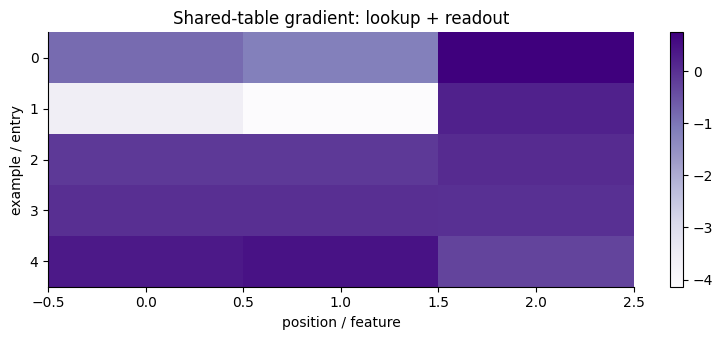

In [19]:
E = torch.randn(5,3, dtype=torch.float64, requires_grad=True)
chosen = torch.tensor([1,2,1]); hidden = E[chosen]
loss = (hidden @ E.T).square().mean()
full = torch.autograd.grad(loss,E)[0]
lookup = torch.autograd.grad((E[chosen] @ E.detach().T).square().mean(),E)[0]
readout = torch.autograd.grad((E.detach()[chosen] @ E.T).square().mean(),E)[0]
assert torch.allclose(full, lookup + readout)
plot_matrix(full, 'Shared-table gradient: lookup + readout')

### ✋ Your turn

How many separate learned tables does this tied calculation own?

In [20]:
answer = None  # Predict, then calculate.

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 1, 'The token table collects gradients from both the input lookup and the output readout.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [21]:
#@title Show a solution { display-mode: "form" }
answer = 1

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 1, 'The token table collects gradients from both the input lookup and the output readout.'
    print("✓ right:", answer)

✓ right: 1


## T3.6 · Does backward change the learned numbers?

**Backward populates gradients; optimizer.step changes parameters; clearing gradients prevents unintended accumulation.**

The scalar loss reaches backward. PyTorch uses the recorded operations to calculate derivatives for the learned parameters.

Each leaf parameter receives its derivative in grad. Intermediate tensors need retain grad if you want to inspect their derivatives too.

The parameter values remain unchanged after backward. The same values produce the same predictions until an update changes them.

A second backward calculation adds to existing gradients. Clear them before an ordinary new step; deliberate accumulation needs deliberate scaling.

$$ \texttt{backward}:L\to\nabla_\theta L\qquad\theta\text{ unchanged} $$

**Look closer.** Autograd records differentiable floating-point operations, not derivatives of integer token ids. The gradient reaches the embedding weights through lookup. Calling loss.item() returns a Python number and disconnects subsequent calculations from the graph.

**Common mistake.** eval() does not disable gradients. no_grad() controls graph recording; model mode controls module behaviour.

In [22]:
torch.manual_seed(1337); model = Prompter(Config())
x,y = batch_from_starts(train_ids,FIX['first']['starts'],32)
before = {n:p.detach().clone() for n,p in model.named_parameters()}
logits, loss = model(x,y); logits.retain_grad(); loss.backward()
expected = (logits.detach().softmax(-1)-F.one_hot(y,65))/y.numel()
assert torch.allclose(logits.grad,expected,atol=1e-8)
assert all(torch.equal(p,before[n]) for n,p in model.named_parameters())
norms = {n:float(p.grad.norm()) for n,p in model.named_parameters()}
print('All parameters unchanged; gradient norms:', norms)

All parameters unchanged; gradient norms: {'head_bias': 0.2106131762266159, 'tok_emb.weight': 0.5260475873947144, 'pos_emb.weight': 0.1573875993490219, 'blocks.0.ln1.weight': 0.001866802922450006, 'blocks.0.ln1.bias': 0.006277160253375769, 'blocks.0.attn.qkv.weight': 0.08679575473070145, 'blocks.0.attn.qkv.bias': 0.06853946298360825, 'blocks.0.attn.proj.weight': 0.08465027064085007, 'blocks.0.attn.proj.bias': 0.6479325890541077, 'blocks.0.ln2.weight': 0.002119835466146469, 'blocks.0.ln2.bias': 0.004598904866725206, 'blocks.0.ff.0.weight': 0.09468857198953629, 'blocks.0.ff.0.bias': 0.049672793596982956, 'blocks.0.ff.2.weight': 0.09524165838956833, 'blocks.0.ff.2.bias': 0.6438364386558533, 'ln_f.weight': 0.0074657718650996685, 'ln_f.bias': 0.018241526558995247}


### ✋ Your turn

Which method changes parameters: backward or step? Store the method name.

In [23]:
answer = None  # Predict, then calculate.

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 'step', 'Backward populates gradients; optimizer.step changes parameters; clearing gradients prevents unintended accumulation.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [24]:
#@title Show a solution { display-mode: "form" }
answer = 'step'

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 'step', 'Backward populates gradients; optimizer.step changes parameters; clearing gradients prevents unintended accumulation.'
    print("✓ right:", answer)

✓ right: step


## Keep connecting the dots

Next: How AdamW changes parameters

Reference: [PyTorch cross-entropy](https://docs.pytorch.org/docs/2.10/generated/torch.nn.CrossEntropyLoss.html), [PyTorch AdamW](https://docs.pytorch.org/docs/2.10/generated/torch.optim.AdamW.html).